In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

# Upload dataset
uploaded = files.upload()

df = pd.read_csv(
    "Metro_Interstate_Traffic_Volume_modified.csv"
)

print("Dataset loaded successfully!")

Libraries imported successfully!


Saving Metro_Interstate_Traffic_Volume_modified.csv to Metro_Interstate_Traffic_Volume_modified.csv
Dataset loaded successfully!


In [ ]:

print("Dataset Shape:", df.shape)

display(df.head())

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape: (48204, 13)


,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume
0,10/2/12 9:00,288.28,0.0,0.0,40.0,0.0,2.30,0.0,NaN,Clouds,scattered clouds,Weekday,5545.0
1,10/2/12 10:00,289.36,0.0,0.0,75.0,0.0,7.45,0.0,NaN,Clouds,broken clouds,Weekday,4516.0
2,10/2/12 11:00,289.58,0.0,0.0,90.0,0.0,5.68,0.0,NaN,Clouds,overcast clouds,Weekday,NaN
3,10/2/12 12:00,290.13,0.0,0.0,90.0,0.0,1.93,0.0,NaN,Clouds,overcast clouds,Weekday,5026.0
4,10/2/12 13:00,NaN,0.0,0.0,75.0,0.0,3.56,0.0,NaN,Clouds,broken clouds,Weekday,4918.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date_time            48204 non-null  object 
 1   temp                 45794 non-null  float64
 2   rain_1h              45792 non-null  float64
 3   snow_1h              45793 non-null  float64
 4   clouds_all           45794 non-null  float64
 5   fog_mm               48204 non-null  float64
 6   wind_speed_ms        48204 non-null  float64
 7   flood_mm             48202 non-null  float64
 8   holiday              61 non-null     object 
 9   weather_main         48204 non-null  object 
 10  weather_description  48204 non-null  object 
 11  day_type             48204 non-null  object 
 12  traffic_volume       45794 non-null  float64
dtypes: float64(8), object(5)
memory usage: 4.8+ MB

Missing Values:
date_time                  0
temp                    2410
rain_1h       

,date_time,temp,rain_1h,snow_1h,clouds_all,fog_mm,wind_speed_ms,flood_mm,holiday,weather_main,weather_description,day_type,traffic_volume
count,48204,45794.000000,45792.000000,45793.000000,45794.000000,48204.000000,48204.000000,48202.000000,61,48204,48204,48204,45794.000000
unique,40575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,11,38,2,NaN
top,4/18/13 22:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Labor Day,Clouds,sky is clear,Weekday,NaN
freq,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,15164,11665,34501,NaN
mean,NaN,281.219070,0.345503,0.000230,49.406931,8.568209,5.396802,0.785051,NaN,NaN,NaN,NaN,3261.366991
std,NaN,13.378092,45.953150,0.008367,39.021861,42.113011,3.548947,8.152681,NaN,NaN,NaN,NaN,1987.139170
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,272.180000,0.000000,0.000000,1.000000,0.000000,2.820000,0.000000,NaN,NaN,NaN,NaN,1195.000000
50%,NaN,282.480000,0.000000,0.000000,64.000000,0.000000,5.050000,0.000000,NaN,NaN,NaN,NaN,3380.000000
75%,NaN,291.830000,0.000000,0.000000,90.000000,0.000000,7.040000,0.000000,NaN,NaN,NaN,NaN,4936.000000


In [ ]:


# Fill missing holiday values
df["holiday"] = df["holiday"].fillna("None")


# Remove observations without target values
df = df.dropna(subset=["traffic_volume"]).copy()



# Remove invalid negative traffic volumes
df = df[df["traffic_volume"] >= 0].copy()



# Parse date using the dataset's month/day/year format
df["date_time"] = pd.to_datetime(
    df["date_time"],format="%m/%d/%y %H:%M",errors="coerce")



# Remove invalid dates
df = df.dropna(subset=["date_time"]).copy()


# Sort chronologically
df = df.sort_values("date_time").reset_index(drop=True)



print("Dataset shape after cleaning:", df.shape)


print("\nMissing values after cleaning:")
print(df.isnull().sum())

Dataset shape after cleaning: (45794, 13)

Missing values after cleaning:
date_time                 0
temp                   2299
rain_1h                2305
snow_1h                2283
clouds_all             2302
fog_mm                    0
wind_speed_ms             0
flood_mm                  2
holiday                   0
weather_main              0
weather_description       0
day_type                  0
traffic_volume            0
dtype: int64


In [ ]:

df["hour"] = df["date_time"].dt.hour

df["month"] = df["date_time"].dt.month

df["day_of_week"] = df["date_time"].dt.dayofweek

df["year"] = df["date_time"].dt.year

print("Time features created successfully!")

display(df[["date_time","hour","month","day_of_week", "year"]].head())

Time features created successfully!


,date_time,hour,month,day_of_week,year
0,2012-10-02 09:00:00,9,10,1,2012
1,2012-10-02 10:00:00,10,10,1,2012
2,2012-10-02 12:00:00,12,10,1,2012
3,2012-10-02 13:00:00,13,10,1,2012
4,2012-10-02 14:00:00,14,10,1,2012


In [ ]:


bins = [0, 1000, 3000, 5000, 10000]

labels = [
    "light",
    "medium",
    "heavy",
    "gridlock"
]

df["traffic_level"] = pd.cut( df["traffic_volume"],bins=bins,labels=labels,include_lowest=True)

# Remove values outside the defined categories
df = df.dropna( subset=["traffic_level"]).copy()

print("Traffic levels created successfully!")

print("\nClass Distribution:")
print(df["traffic_level"].value_counts())

print("\nClass Distribution (%):")
print( df["traffic_level"].value_counts(normalize=True).mul(100).round(2))

Traffic levels created successfully!

Class Distribution:
traffic_level
heavy       14538
gridlock    10807
light       10420
medium      10029
Name: count, dtype: int64

Class Distribution (%):
traffic_level
heavy       31.75
gridlock    23.60
light       22.75
medium      21.90
Name: proportion, dtype: float64


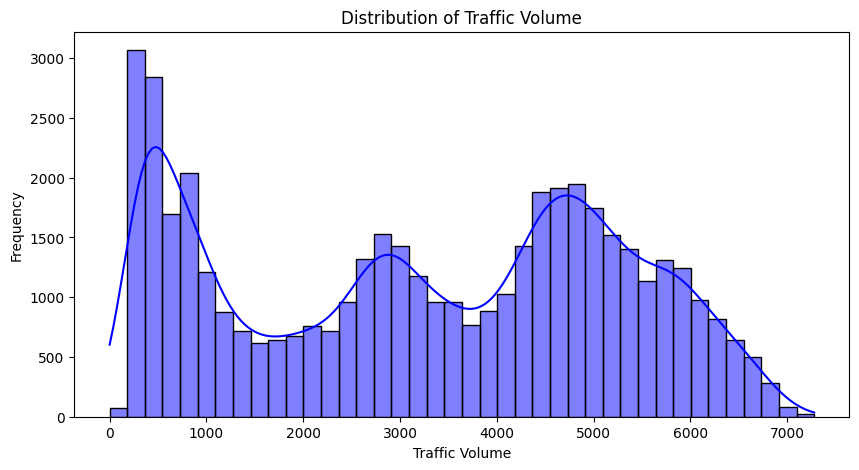

In [ ]:

plt.figure(figsize=(10, 5))

sns.histplot(df["traffic_volume"], bins=40,kde=True, color="blue")

plt.title("Distribution of Traffic Volume")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

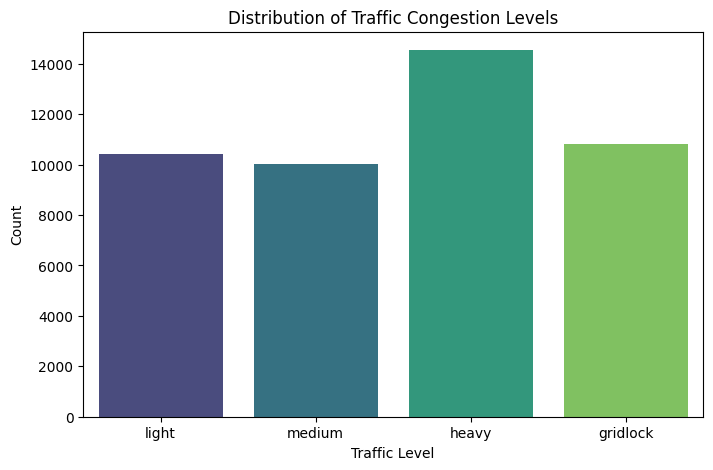

In [ ]:

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="traffic_level",
    order=labels,
    hue="traffic_level",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Traffic Congestion Levels")
plt.xlabel("Traffic Level")
plt.ylabel("Count")

plt.show()

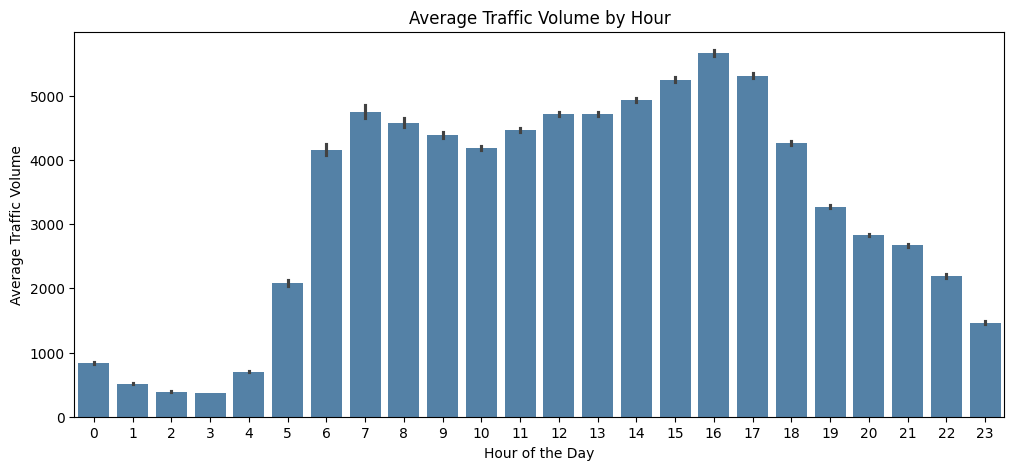

In [ ]:

plt.figure(figsize=(12, 5))

sns.barplot(
    data=df,
    x="hour",
    y="traffic_volume",
    color="steelblue"
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Traffic Volume")

plt.show()

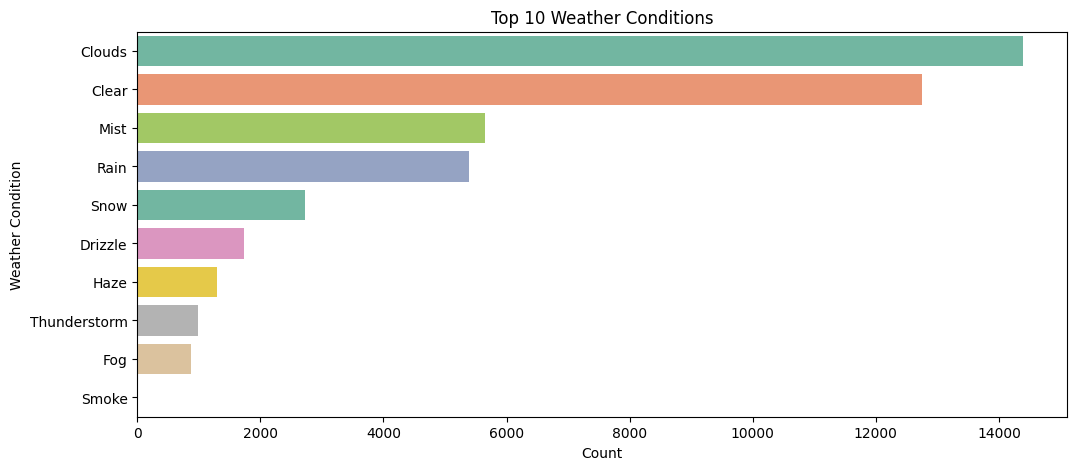

In [ ]:

plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    y="weather_main",
    order=df["weather_main"].value_counts().index[:10],
    hue="weather_main",
    palette="Set2",
    legend=False
)

plt.title("Top 10 Weather Conditions")
plt.xlabel("Count")
plt.ylabel("Weather Condition")

plt.show()

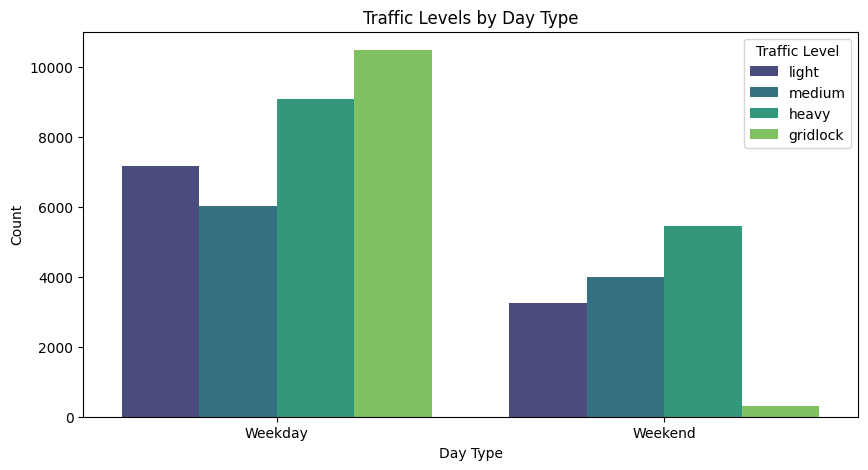

In [ ]:

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="day_type",
    hue="traffic_level",
    hue_order=labels,
    palette="viridis"
)

plt.title("Traffic Levels by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Count")

plt.legend(title="Traffic Level")

plt.show()

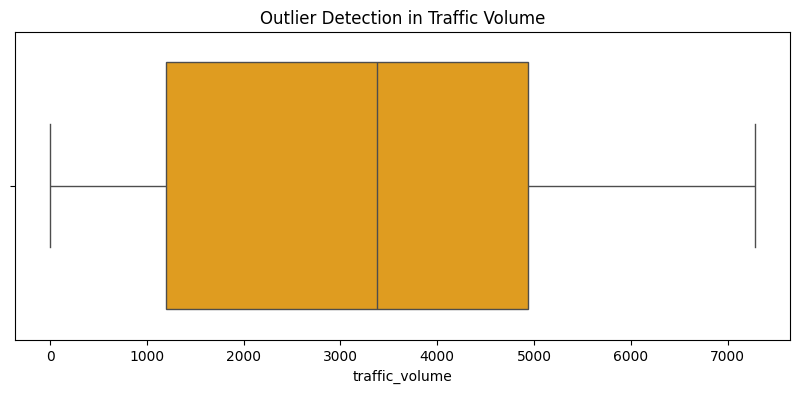

Q1: 1195.0
Q3: 4936.0
IQR: 3741.0
Lower Bound: -4416.5
Upper Bound: 10547.5
Number of Outliers: 0


In [ ]:


plt.figure(figsize=(10, 4))

sns.boxplot(x=df["traffic_volume"], color="orange")

plt.title("Outlier Detection in Traffic Volume")

plt.show()

Q1 = df["traffic_volume"].quantile(0.25)

Q3 = df["traffic_volume"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["traffic_volume"] < lower_bound) | (df["traffic_volume"] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Number of Outliers:", len(outliers))

In [ ]:

y = df["traffic_level"].astype(str)

X = df.drop(columns=[ "date_time","traffic_volume", "traffic_level","weather_description"], errors="ignore")

categorical_features = [ "weather_main","day_type","holiday"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nFeature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

Numerical Features:
['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'fog_mm', 'wind_speed_ms', 'flood_mm', 'hour', 'month', 'day_of_week', 'year']

Categorical Features:
['weather_main', 'day_type', 'holiday']

Feature Matrix Shape: (45794, 14)
Target Shape: (45794,)


In [ ]:

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index].copy()

X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()

y_test = y.iloc[split_index:].copy()

print("X_train shape:", X_train.shape)

print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)

print("y_test shape:", y_test.shape)

print("\nTraining period:")
print(df["date_time"].iloc[0],"to", df["date_time"].iloc[split_index - 1])

print("\nTesting period:")
print(df["date_time"].iloc[split_index],"to",df["date_time"].iloc[-1])

X_train shape: (36635, 14)
X_test shape: (9159, 14)
y_train shape: (36635,)
y_test shape: (9159,)

Training period:
2012-10-02 09:00:00 to 2017-11-01 12:00:00

Testing period:
2017-11-01 13:00:00 to 2018-09-30 23:00:00


In [ ]:

numerical_transformer = Pipeline(
    steps=[ ( "imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler() )])

categorical_transformer = Pipeline(
    steps=[( "imputer",SimpleImputer(strategy="most_frequent")),( "encoder", OneHotEncoder(handle_unknown="ignore"))])


preprocessor = ColumnTransformer(
    transformers=[( "num",numerical_transformer,numerical_features),("cat",categorical_transformer,categorical_features)])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:

models = {

    "Logistic Regression": LogisticRegression( max_iter=2000,class_weight="balanced",random_state=42),

    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",random_state=42,n_jobs=-1),

    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=42)

}

trained_models = {}

for name, classifier in models.items():

    print("\nTraining:", name)

    pipeline = Pipeline( steps=[("preprocessor", preprocessor),("classifier", classifier)])

    pipeline.fit(X_train,y_train)

    trained_models[name] = pipeline

    print(name, "trained successfully!")


Training: Logistic Regression
Logistic Regression trained successfully!

Training: Random Forest
Random Forest trained successfully!

Training: Decision Tree
Decision Tree trained successfully!


In [ ]:

results = []

predictions = {}

for name, model in trained_models.items():

    print("\n" + "=" * 60)

    print("MODEL:", name)

    print("=" * 60)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    predictions[name] = test_pred

    train_accuracy = accuracy_score(y_train,train_pred)

    test_accuracy = accuracy_score(y_test,test_pred)

    precision = precision_score(y_test,test_pred,average="weighted",zero_division=0)

    recall = recall_score( y_test, test_pred,average="weighted",zero_division=0)

    f1 = f1_score( y_test,test_pred,average="weighted",zero_division=0)

    gap = abs(train_accuracy - test_accuracy) * 100

    results.append({"Model": name, "Train Accuracy (%)": train_accuracy * 100, "Test Accuracy (%)":test_accuracy * 100, "Precision (%)": precision * 100,
                    "Recall (%)":recall * 100,"F1-Score (%)":f1 * 100, "Accuracy Gap (%)":gap  })

    print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

    print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

    print( f"Precision: {precision * 100:.2f}%" )

    print(f"Recall: {recall * 100:.2f}%")

    print(f"F1-Score: {f1 * 100:.2f}%")

    print( f"Accuracy Gap: {gap:.2f}%")

    print("\nClassification Report:")

    print( classification_report(y_test, test_pred,labels=labels,zero_division=0) )


MODEL: Logistic Regression
Training Accuracy: 61.81%
Testing Accuracy: 60.29%
Precision: 59.63%
Recall: 60.29%
F1-Score: 58.93%
Accuracy Gap: 1.52%

Classification Report:
              precision    recall  f1-score   support

       light       0.79      0.94      0.86      2072
      medium       0.46      0.53      0.49      1923
       heavy       0.57      0.37      0.45      3073
    gridlock       0.57      0.68      0.62      2091

    accuracy                           0.60      9159
   macro avg       0.60      0.63      0.60      9159
weighted avg       0.60      0.60      0.59      9159


MODEL: Random Forest
Training Accuracy: 100.00%
Testing Accuracy: 83.46%
Precision: 83.67%
Recall: 83.46%
F1-Score: 83.54%
Accuracy Gap: 16.54%

Classification Report:
              precision    recall  f1-score   support

       light       0.98      0.94      0.96      2072
      medium       0.81      0.80      0.81      1923
       heavy       0.78      0.79      0.78      3073
    gr

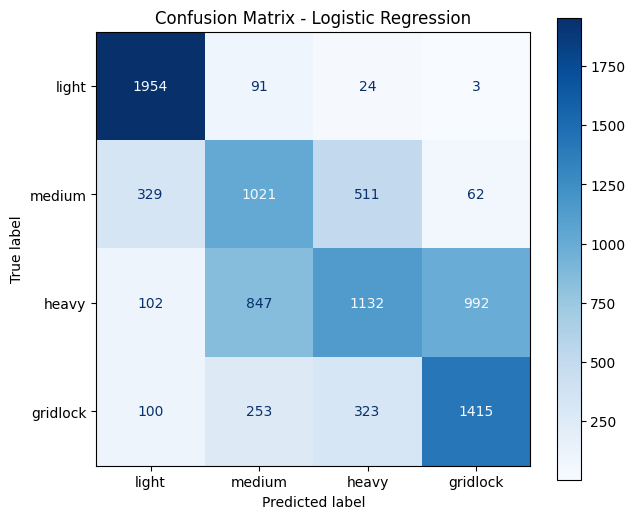

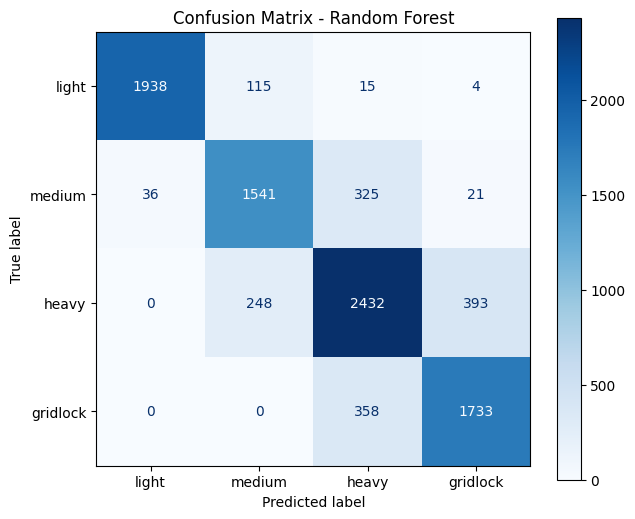

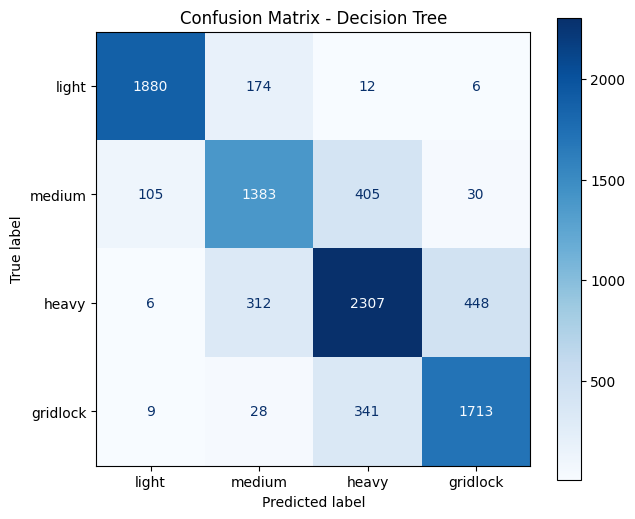

In [ ]:

for name, model in trained_models.items():

    y_pred = predictions[name]

    cm = confusion_matrix( y_test,y_pred,labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labels)

    fig, ax = plt.subplots(figsize=(7, 6))

    disp.plot(cmap="Blues", values_format="d",ax=ax )

    plt.title( f"Confusion Matrix - {name}")

    plt.show()

In [ ]:
#FINAL MODEL COMPARISON


comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.round(2)

print("FINAL MODEL COMPARISON")

display(comparison_df)

FINAL MODEL COMPARISON


,Model,Train Accuracy (%),Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),Accuracy Gap (%)
0,Logistic Regression,61.81,60.29,59.63,60.29,58.93,1.52
1,Random Forest,100.00,83.46,83.67,83.46,83.54,16.54
2,Decision Tree,100.00,79.52,79.63,79.52,79.55,20.48


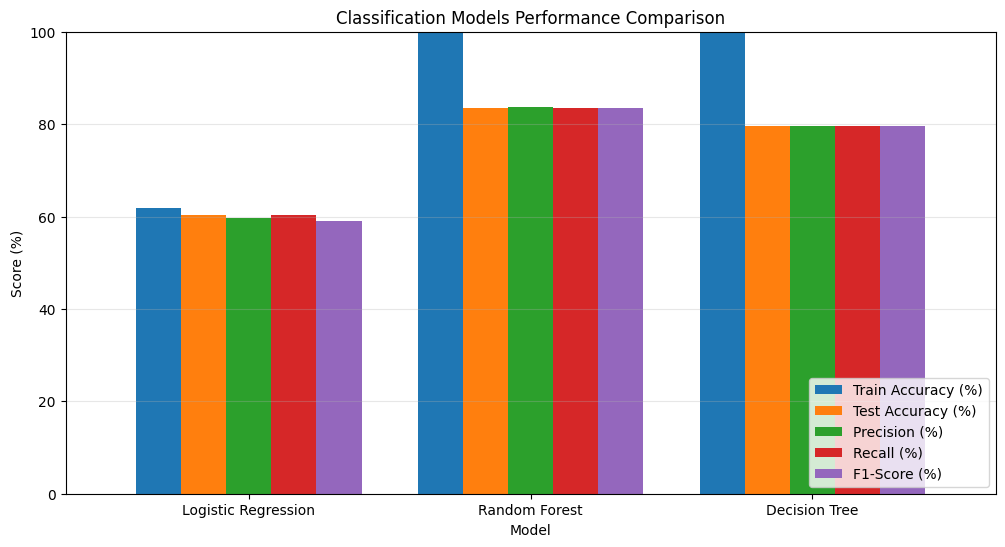

In [ ]:
#  PERFORMANCE COMPARISON CHART


metrics = [
    "Train Accuracy (%)",
    "Test Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)"
]

comparison_df.set_index("Model")[metrics].plot(kind="bar", figsize=(12, 6),ylim=(0, 100),width=0.8)

plt.title("Classification Models Performance Comparison")

plt.ylabel("Score (%)")

plt.xlabel("Model")

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.grid(axis="y", alpha=0.3)

plt.show()

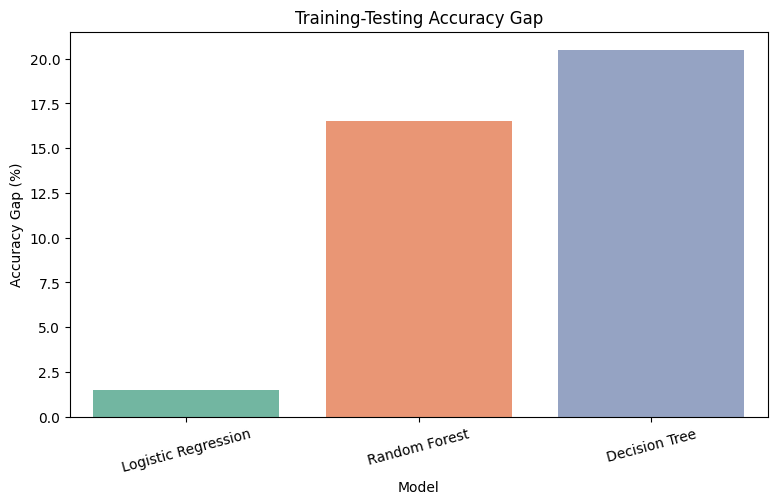

In [ ]:
# ACCURACY GAP COMPARISON

plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy Gap (%)",
    hue="Model",
    palette="Set2",
    legend=False
)

plt.title("Training-Testing Accuracy Gap")

plt.ylabel("Accuracy Gap (%)")

plt.xlabel("Model")

plt.xticks(rotation=15)

plt.show()

Top 15 Important Features:


,Feature,Importance
7,num__hour,0.578323
0,num__temp,0.109390
5,num__wind_speed_ms,0.088748
9,num__day_of_week,0.046596
8,num__month,0.043370
3,num__clouds_all,0.031085
10,num__year,0.028581
22,cat__day_type_Weekday,0.015400
23,cat__day_type_Weekend,0.013373
4,num__fog_mm,0.012923


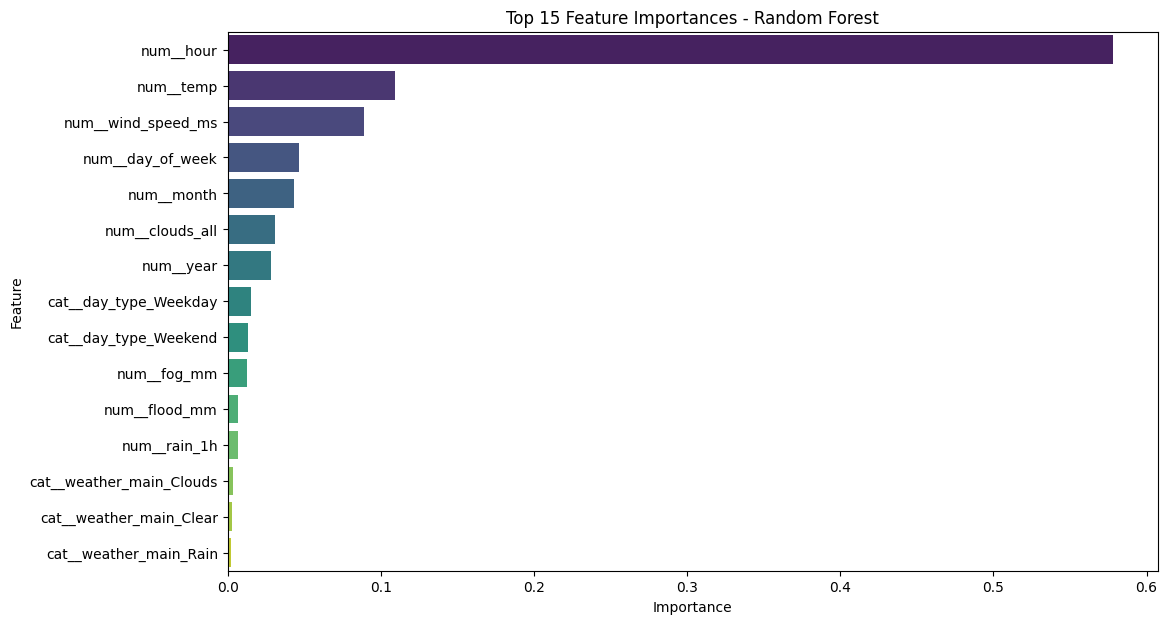

In [ ]:

rf_model = trained_models["Random Forest"]

fitted_preprocessor = (rf_model.named_steps["preprocessor"])

rf_classifier = (rf_model.named_steps["classifier"])

feature_names = ( fitted_preprocessor.get_feature_names_out())

importances = (rf_classifier.feature_importances_)

importance_df = pd.DataFrame({ "Feature": feature_names, "Importance": importances})

importance_df = importance_df.sort_values( by="Importance",ascending=False)

print("Top 15 Important Features:")

display(importance_df.head(15))

# Plot feature importance
plt.figure(figsize=(12, 7))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 15 Feature Importances - Random Forest")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()